# BirdCLEF+ 2026 - Insightful EDA

Purpose: understand the dataset shape, label imbalance, taxonomy coverage, duration/chunking strategy, secondary-label noise, soundscape annotations, and representative audio examples.

Artifacts are written to `/kaggle/working/artifacts/eda`.


## 1. Setup


In [1]:
from pathlib import Path
import json
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)


class CFG:
    seed = 42
    competition_name = "birdclef-2026"
    data_root = None
    artifact_dir = Path("/kaggle/working/artifacts")


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


def find_data_root() -> Path:
    candidates = [
        Path("/kaggle/input/birdclef-2026"),
        Path("/kaggle/input/birdclef-2026-repack/birdclef-2026"),
        Path("/kaggle/input/birdclef-2026-repack"),
        Path("data/raw/birdclef-2026"),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    input_root = Path("/kaggle/input")
    if input_root.exists():
        matches = list(input_root.glob("**/train.csv"))
        if matches:
            return matches[0].parent
    raise FileNotFoundError("Could not find train.csv. Attach the BirdCLEF 2026 dataset.")


def read_optional_csv(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None


seed_everything(CFG.seed)
CFG.data_root = find_data_root()
CFG.artifact_dir.mkdir(parents=True, exist_ok=True)

print(f"Data root: {CFG.data_root}")
print(f"Artifacts: {CFG.artifact_dir}")

import ast
from collections import Counter

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display

CFG.artifact_dir = CFG.artifact_dir / "eda"
CFG.artifact_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")


class CFG(CFG):
    sample_rate = 32000
    clip_seconds = 5
    n_mels = 128
    top_n = 30
    random_examples = 6


Data root: /kaggle/input/competitions/birdclef-2026
Artifacts: /kaggle/working/artifacts


## 2. Load Metadata


In [2]:
def parse_label_list(value) -> list[str]:
    if isinstance(value, list):
        return [str(x) for x in value]
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return [str(x) for x in parsed] if isinstance(parsed, list) else []


train = pd.read_csv(CFG.data_root / "train.csv")
taxonomy = read_optional_csv(CFG.data_root / "taxonomy.csv")
soundscape_labels = read_optional_csv(CFG.data_root / "train_soundscapes_labels.csv")
sample_submission = read_optional_csv(CFG.data_root / "sample_submission.csv")

train["filepath"] = train["filename"].map(lambda x: CFG.data_root / "train_audio" / x)
if "secondary_labels" in train.columns:
    train["secondary_labels"] = train["secondary_labels"].map(parse_label_list)
else:
    train["secondary_labels"] = [[] for _ in range(len(train))]

if taxonomy is not None and "primary_label" in taxonomy.columns:
    train = train.merge(taxonomy, on="primary_label", how="left", suffixes=("", "_taxonomy"))

summary = {
    "train_rows": len(train),
    "primary_classes": train["primary_label"].nunique(),
    "taxonomy_rows": 0 if taxonomy is None else len(taxonomy),
    "soundscape_label_rows": 0 if soundscape_labels is None else len(soundscape_labels),
    "sample_submission_rows": 0 if sample_submission is None else len(sample_submission),
    "audio_files_found": int(train["filepath"].map(Path.exists).sum()),
}
pd.Series(summary).to_csv(CFG.artifact_dir / "dataset_summary.csv", header=["value"])
display(pd.Series(summary).to_frame("value"))
display(train.head())


,value
train_rows,35549
primary_classes,206
taxonomy_rows,234
soundscape_label_rows,1478
sample_submission_rows,3
audio_files_found,35549


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,filepath,inat_taxon_id_taxonomy,scientific_name_taxonomy,common_name_taxonomy,class_name_taxonomy
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,/kaggle/input/competitions/birdclef-2026/train...,1161364,Guyalna cuta,Guyalna cuta,Insecta


## 3. Dataset Schema And Missingness


In [3]:
def safe_nunique(series: pd.Series) -> int:
    values = series.map(lambda x: tuple(x) if isinstance(x, list) else x)
    return int(values.nunique(dropna=True))


schema = pd.DataFrame(
    {
        "column": train.columns,
        "dtype": [str(train[col].dtype) for col in train.columns],
        "missing": [int(train[col].isna().sum()) for col in train.columns],
        "missing_pct": [float(train[col].isna().mean()) for col in train.columns],
        "unique": [safe_nunique(train[col]) for col in train.columns],
    }
)
schema.to_csv(CFG.artifact_dir / "train_schema_missingness.csv", index=False)
display(schema)

missing_files = train.loc[~train["filepath"].map(Path.exists), ["filename", "filepath"]]
missing_files.to_csv(CFG.artifact_dir / "missing_audio_files.csv", index=False)
print(f"Missing audio files: {len(missing_files):,}")


,column,dtype,missing,missing_pct,unique
0,primary_label,object,0,0.0,206
1,secondary_labels,object,0,0.0,1517
2,type,object,0,0.0,755
3,latitude,float64,0,0.0,15270
4,longitude,float64,0,0.0,15265
5,scientific_name,object,0,0.0,206
6,common_name,object,0,0.0,206
7,class_name,object,0,0.0,5
8,inat_taxon_id,int64,0,0.0,206
9,author,object,0,0.0,4017


Missing audio files: 0


## 4. Primary Label Imbalance


Top 10 classes contain 13.9% of recordings.
Singleton classes: 4


,primary_label,recordings,share,cumulative_share,imbalance_ratio_vs_median
0,rubthr1,499,0.014037,0.014037,3.992
1,banana,498,0.014009,0.028046,3.984
2,fepowl,497,0.013981,0.042026,3.976
3,soulap1,497,0.013981,0.056007,3.976
4,houspa,496,0.013953,0.069960,3.968
5,coffal1,495,0.013924,0.083884,3.960
6,osprey,495,0.013924,0.097809,3.960
7,socfly1,494,0.013896,0.111705,3.952
8,compau,493,0.013868,0.125573,3.944
9,yeofly1,493,0.013868,0.139441,3.944


,primary_label,recordings,share,cumulative_share,imbalance_ratio_vs_median
176,1176823,12,0.000338,0.996006,0.096
177,1161364,11,0.000309,0.996315,0.088
178,24287,11,0.000309,0.996624,0.088
179,74113,10,0.000281,0.996906,0.080
180,22983,10,0.000281,0.997187,0.080
181,555145,9,0.000253,0.997440,0.072
182,22967,8,0.000225,0.997665,0.064
183,760266,7,0.000197,0.997862,0.056
184,67252,6,0.000169,0.998031,0.048
185,22985,6,0.000169,0.998200,0.048


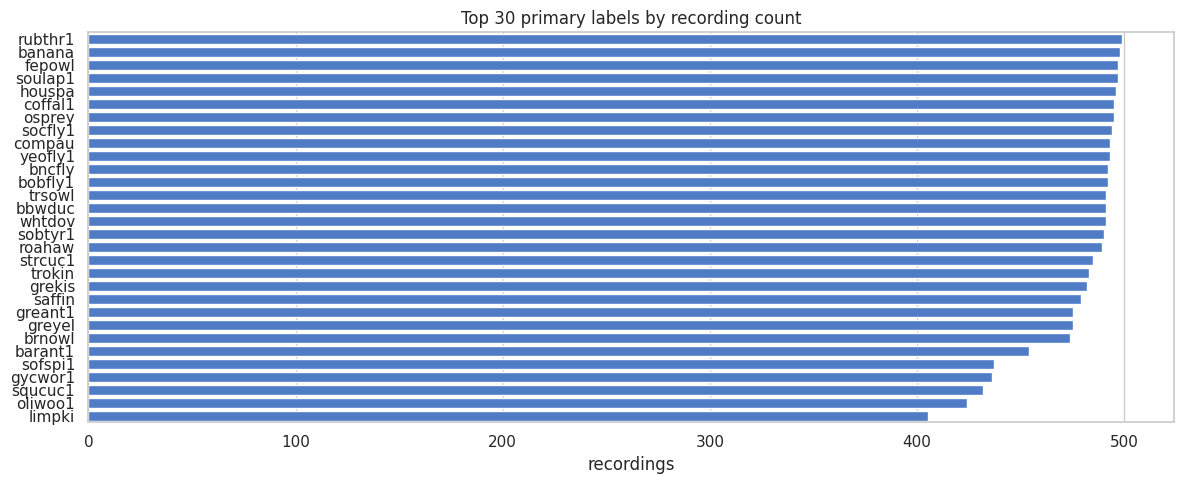

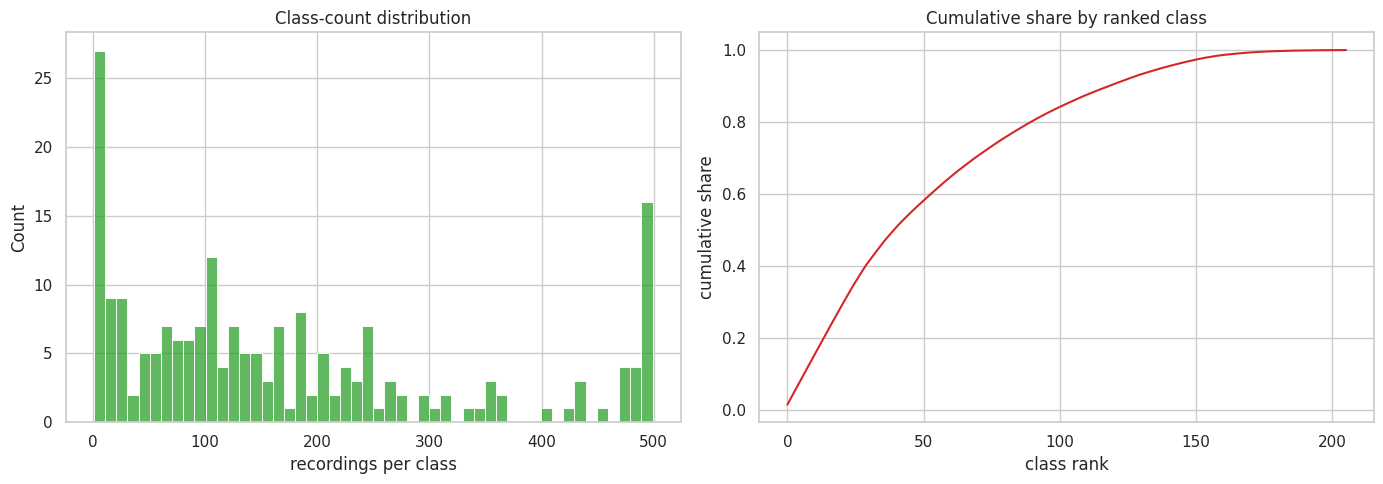

In [4]:
label_counts = (
    train["primary_label"]
    .value_counts()
    .rename_axis("primary_label")
    .reset_index(name="recordings")
)
label_counts["share"] = label_counts["recordings"] / label_counts["recordings"].sum()
label_counts["cumulative_share"] = label_counts["share"].cumsum()
label_counts["imbalance_ratio_vs_median"] = label_counts["recordings"] / label_counts["recordings"].median()
label_counts.to_csv(CFG.artifact_dir / "primary_label_counts.csv", index=False)

head_share = label_counts.head(10)["share"].sum()
tail_singletons = int((label_counts["recordings"] == 1).sum())
print(f"Top 10 classes contain {head_share:.1%} of recordings.")
print(f"Singleton classes: {tail_singletons:,}")
display(label_counts.head(CFG.top_n))
display(label_counts.tail(CFG.top_n))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=label_counts.head(CFG.top_n), x="recordings", y="primary_label", ax=ax, color="#3C78D8")
ax.set_title(f"Top {CFG.top_n} primary labels by recording count")
ax.set_xlabel("recordings")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(CFG.artifact_dir / "top_primary_labels.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(label_counts["recordings"], bins=50, ax=axes[0], color="#2CA02C")
axes[0].set_title("Class-count distribution")
axes[0].set_xlabel("recordings per class")
sns.lineplot(data=label_counts.reset_index(), x="index", y="cumulative_share", ax=axes[1], color="#D62728")
axes[1].set_title("Cumulative share by ranked class")
axes[1].set_xlabel("class rank")
axes[1].set_ylabel("cumulative share")
fig.tight_layout()
fig.savefig(CFG.artifact_dir / "class_imbalance_diagnostics.png", dpi=160)
plt.show()


## 5. Duration And Chunking Implications


In [5]:
if "duration" in train.columns:
    duration_summary = train["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    duration_summary.to_csv(CFG.artifact_dir / "duration_summary.csv", header=["value"])
    display(duration_summary)

    duration_by_label = (
        train.groupby("primary_label")["duration"]
        .agg(recordings="count", median_duration="median", total_seconds="sum")
        .reset_index()
        .sort_values("total_seconds", ascending=False)
    )
    duration_by_label["estimated_5s_chunks"] = np.ceil(duration_by_label["total_seconds"] / CFG.clip_seconds).astype(int)
    duration_by_label.to_csv(CFG.artifact_dir / "duration_by_primary_label.csv", index=False)
    display(duration_by_label.head(20))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    clipped = train["duration"].clip(upper=train["duration"].quantile(0.99))
    sns.histplot(clipped, bins=60, ax=axes[0], color="#9467BD")
    axes[0].set_title("Audio duration distribution, clipped at p99")
    axes[0].set_xlabel("seconds")
    sns.scatterplot(
        data=duration_by_label,
        x="recordings",
        y="total_seconds",
        size="median_duration",
        sizes=(20, 180),
        alpha=0.7,
        ax=axes[1],
        color="#FF7F0E",
    )
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title("Per-class recording count vs total audio")
    axes[1].set_xlabel("recordings, log scale")
    axes[1].set_ylabel("total seconds, log scale")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "duration_and_chunking.png", dpi=160)
    plt.show()
else:
    print("No duration column found in train.csv.")


No duration column found in train.csv.


## 6. Secondary Labels And Co-Occurrence


Rows with secondary labels: 4,372 (12.3%)


,secondary_label,mentions
0,grekis,624
1,whtdov,468
2,undtin1,315
3,yecpar,226
4,rufhor2,225
5,saffin,183
6,picpig2,172
7,trokin,171
8,soulap1,154
9,grasal3,151


,primary_label,secondary_labels,count
1212,grasal3,grekis,16
2612,saffin,grekis,16
2949,socfly1,grekis,15
2422,rufhor2,grekis,15
402,bncfly,whtdov,15
3232,strcuc1,grekis,15
1318,greant1,whtdov,14
419,bobfly1,grekis,14
3860,yebela1,trokin,14
1104,fusfly1,whtdov,13


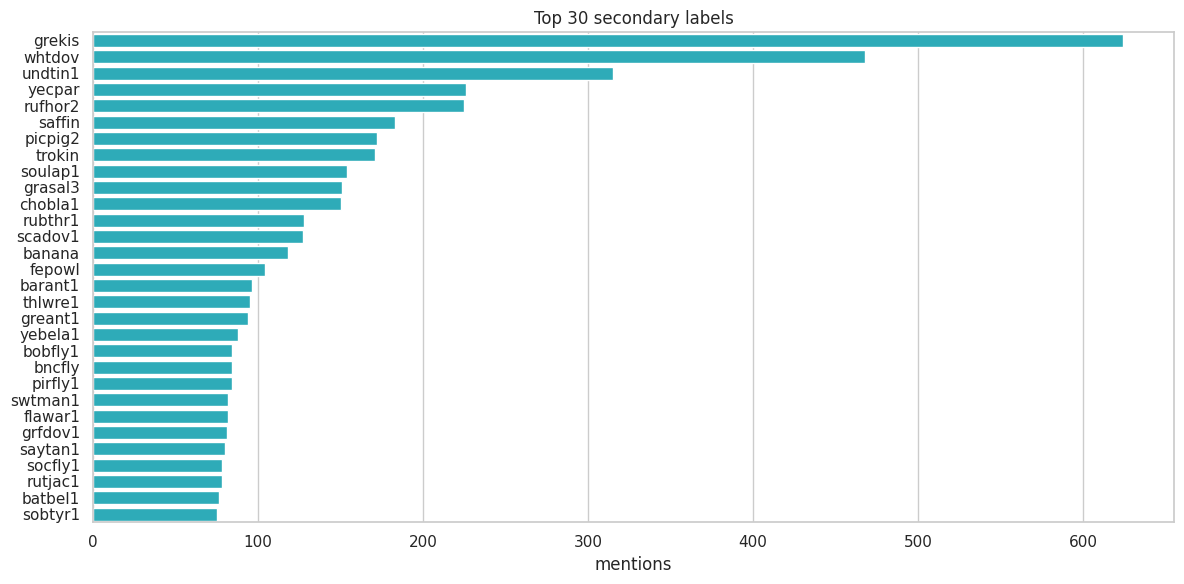

In [6]:
secondary = train[["filename", "primary_label", "secondary_labels"]].explode("secondary_labels")
secondary = secondary.dropna(subset=["secondary_labels"])
secondary_counts = (
    secondary["secondary_labels"]
    .value_counts()
    .rename_axis("secondary_label")
    .reset_index(name="mentions")
)
secondary_counts.to_csv(CFG.artifact_dir / "secondary_label_counts.csv", index=False)
rows_with_secondary = int((train["secondary_labels"].map(len) > 0).sum())
print(f"Rows with secondary labels: {rows_with_secondary:,} ({rows_with_secondary / len(train):.1%})")
display(secondary_counts.head(CFG.top_n))

cooccurrence = (
    secondary.groupby(["primary_label", "secondary_labels"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
cooccurrence.to_csv(CFG.artifact_dir / "primary_secondary_cooccurrence.csv", index=False)
display(cooccurrence.head(30))

if len(secondary_counts):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=secondary_counts.head(CFG.top_n), x="mentions", y="secondary_label", ax=ax, color="#17BECF")
    ax.set_title(f"Top {CFG.top_n} secondary labels")
    ax.set_xlabel("mentions")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "top_secondary_labels.png", dpi=160)
    plt.show()


## 7. Taxonomy Coverage


In [7]:
if taxonomy is not None:
    taxonomy.to_csv(CFG.artifact_dir / "taxonomy_copy.csv", index=False)
    display(taxonomy.head())
    taxonomy_cols = taxonomy.columns.tolist()
    print(taxonomy_cols)

    taxonomy_label_col = "primary_label" if "primary_label" in taxonomy.columns else None
    if taxonomy_label_col:
        train_labels = set(pd.read_csv(CFG.data_root / "train.csv")["primary_label"].unique())
        taxonomy_labels = set(taxonomy[taxonomy_label_col].dropna().astype(str).unique())
        coverage = {
            "train_labels": len(train_labels),
            "taxonomy_labels": len(taxonomy_labels),
            "train_labels_missing_from_taxonomy": len(train_labels - taxonomy_labels),
            "taxonomy_labels_not_in_train": len(taxonomy_labels - train_labels),
        }
        pd.Series(coverage).to_csv(CFG.artifact_dir / "taxonomy_coverage.csv", header=["value"])
        display(pd.Series(coverage).to_frame("value"))

    candidate_cols = [c for c in ["class_name", "order", "family", "genus", "species", "common_name", "scientific_name"] if c in train.columns]
    for col in candidate_cols[:4]:
        counts = train[col].value_counts(dropna=False).head(20).rename_axis(col).reset_index(name="recordings")
        display(counts)
else:
    print("No taxonomy.csv found.")


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


,value
train_labels,206
taxonomy_labels,234
train_labels_missing_from_taxonomy,0
taxonomy_labels_not_in_train,28


,class_name,recordings
0,Aves,34799
1,Amphibia,451
2,Insecta,199
3,Mammalia,99
4,Reptilia,1


,common_name,recordings
0,Rufous-bellied Thrush,499
1,Bananaquit,498
2,Ferruginous Pygmy Owl,497
3,Southern Lapwing,497
4,House Sparrow,496
5,Collared Forest-Falcon,495
6,Osprey,495
7,Social Flycatcher,494
8,Pauraque,493
9,Yellow-olive Flatbill,493


,scientific_name,recordings
0,Turdus rufiventris,499
1,Coereba flaveola,498
2,Glaucidium brasilianum,497
3,Vanellus chilensis,497
4,Passer domesticus,496
5,Micrastur semitorquatus,495
6,Pandion haliaetus,495
7,Myiozetetes similis,494
8,Nyctidromus albicollis,493
9,Tolmomyias sulphurescens,493


## 8. Soundscape Labels


In [8]:
if soundscape_labels is None:
    print("No train_soundscapes_labels.csv found.")
else:
    soundscape_labels.to_csv(CFG.artifact_dir / "soundscape_labels_copy.csv", index=False)
    display(soundscape_labels.head())
    print(soundscape_labels.columns.tolist())

    label_like_cols = [c for c in soundscape_labels.columns if "label" in c.lower() or "species" in c.lower() or "code" in c.lower()]
    time_like_cols = [c for c in soundscape_labels.columns if "time" in c.lower() or "second" in c.lower()]
    file_like_cols = [c for c in soundscape_labels.columns if "filename" in c.lower() or "soundscape" in c.lower() or "row_id" in c.lower()]

    soundscape_summary = {
        "rows": len(soundscape_labels),
        "columns": len(soundscape_labels.columns),
        "label_like_columns": ", ".join(label_like_cols),
        "time_like_columns": ", ".join(time_like_cols),
        "file_like_columns": ", ".join(file_like_cols),
    }
    pd.Series(soundscape_summary).to_csv(CFG.artifact_dir / "soundscape_summary.csv", header=["value"])
    display(pd.Series(soundscape_summary).to_frame("value"))

    if label_like_cols:
        col = label_like_cols[0]
        sc_counts = soundscape_labels[col].value_counts().head(CFG.top_n).rename_axis(col).reset_index(name="rows")
        sc_counts.to_csv(CFG.artifact_dir / "soundscape_label_counts.csv", index=False)
        display(sc_counts)


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


['filename', 'start', 'end', 'primary_label']


,value
rows,1478
columns,4
label_like_columns,primary_label
time_like_columns,
file_like_columns,filename


,primary_label,rows
0,23158;24279;24321;517063;555146;65380;66971,54
1,24321;555146;65380;66971,36
2,517063,36
3,22973;517063;555146;65380,28
4,24279;24321;555146;65380;66971,26
5,23158;24279;24321;555146;65380;66971,26
6,516975,24
7,1491113;22967;22973;23158,24
8,22961;23158;24279;517063;555146;65380,24
9,23158;24321;25092;65380;66971,24


## 9. Representative Audio And Spectrograms


,filename,primary_label
0,23176/XC929082.ogg,23176
1,22973/XC892927.ogg,22973
2,yebela1/iNat1696413.ogg,yebela1
3,fabwre1/XC2199.ogg,fabwre1
4,camfli1/XC685648.ogg,camfli1
5,gretho2/XC589406.ogg,gretho2


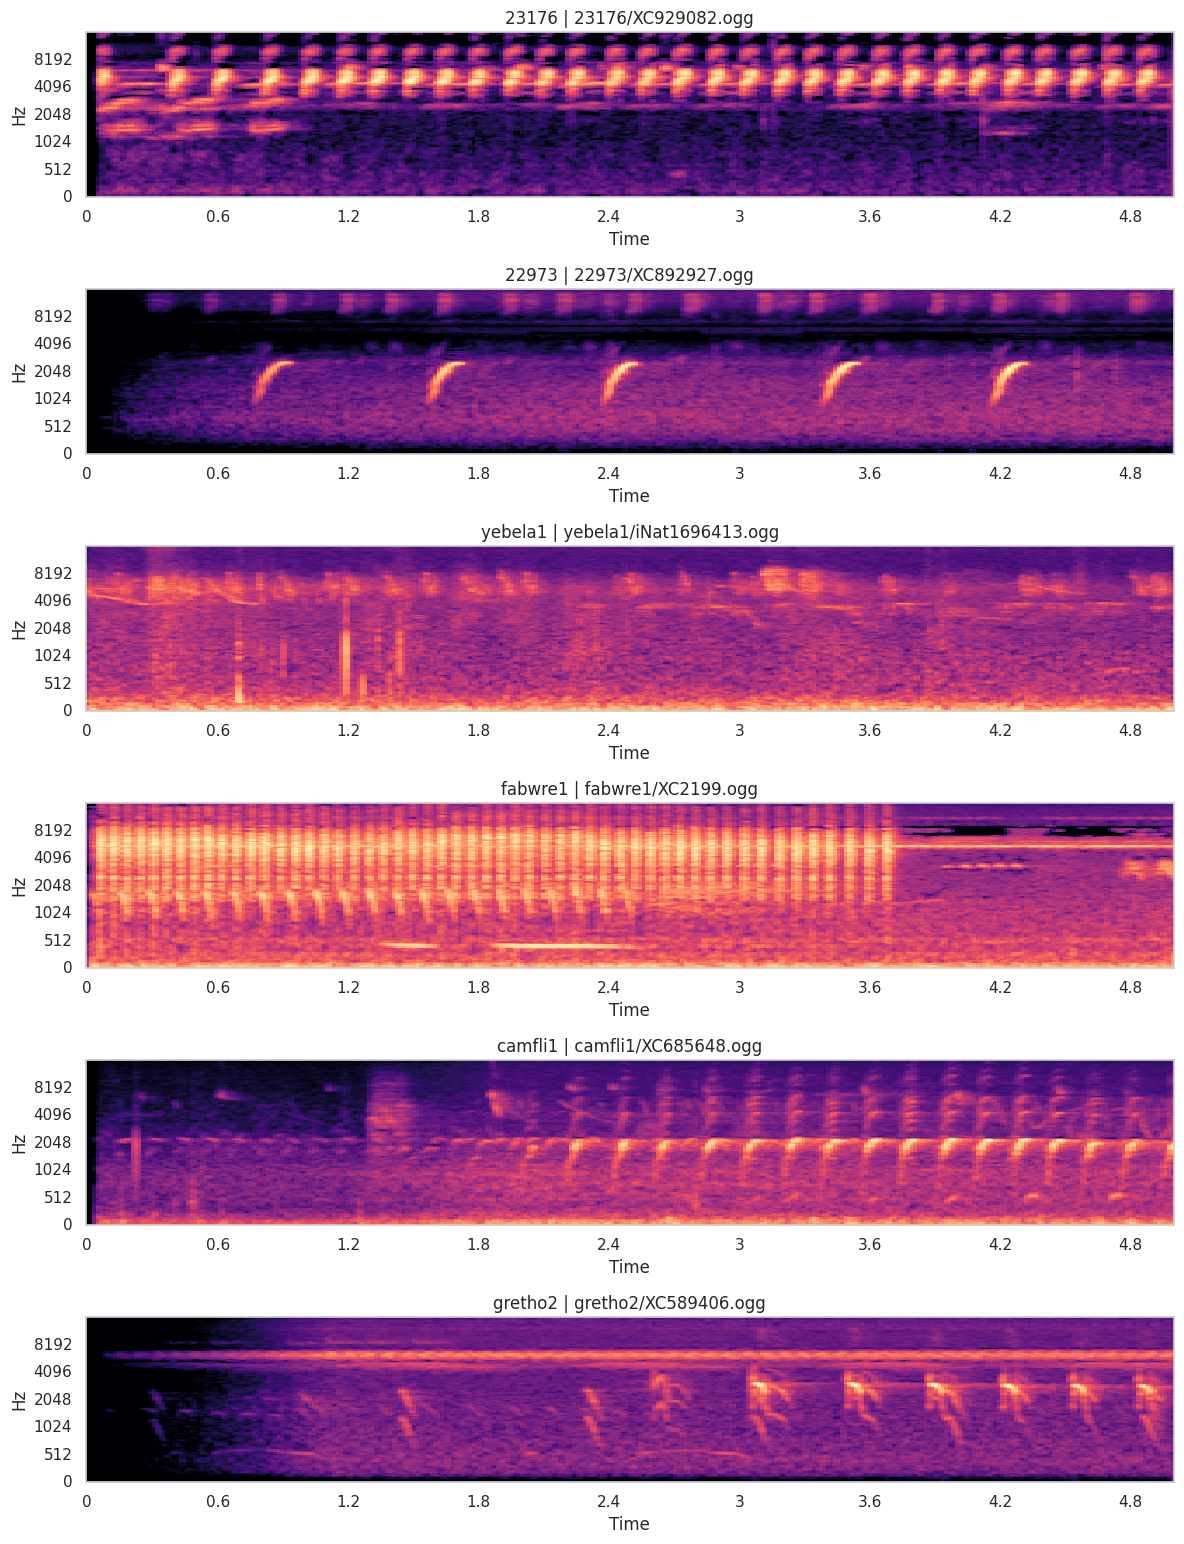

Audio preview: 23176 | 23176/XC929082.ogg


In [9]:
def load_clip(path: Path, seconds: float = 5.0) -> np.ndarray:
    y, _ = librosa.load(path, sr=CFG.sample_rate, mono=True, duration=seconds)
    target_len = int(CFG.sample_rate * seconds)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y[:target_len].astype(np.float32)


available = train[train["filepath"].map(Path.exists)].copy()
if len(available) == 0:
    print("No local audio files available for previews.")
else:
    example_df = (
        available.groupby("primary_label", group_keys=False)
        .apply(lambda x: x.sample(1, random_state=CFG.seed))
        .sample(min(CFG.random_examples, available["primary_label"].nunique()), random_state=CFG.seed)
        .reset_index(drop=True)
    )
    example_df[["filename", "primary_label"]].to_csv(CFG.artifact_dir / "audio_examples.csv", index=False)
    display(example_df[["filename", "primary_label"]])

    fig, axes = plt.subplots(len(example_df), 1, figsize=(12, 2.6 * len(example_df)))
    axes = np.atleast_1d(axes)
    for ax, (_, row) in zip(axes, example_df.iterrows()):
        y = load_clip(row["filepath"], CFG.clip_seconds)
        mel = librosa.feature.melspectrogram(y=y, sr=CFG.sample_rate, n_mels=CFG.n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=CFG.sample_rate, x_axis="time", y_axis="mel", ax=ax)
        ax.set_title(f"{row['primary_label']} | {row['filename']}")
    fig.tight_layout()
    fig.savefig(CFG.artifact_dir / "representative_mels.png", dpi=160)
    plt.show()

    first = example_df.iloc[0]
    print(f"Audio preview: {first['primary_label']} | {first['filename']}")
    display(Audio(load_clip(first["filepath"], CFG.clip_seconds), rate=CFG.sample_rate))


## 10. Modeling Takeaways


In [10]:
takeaways = []
takeaways.append(
    f"Primary-label imbalance is substantial: top 10 classes cover {label_counts.head(10)['share'].sum():.1%} of training recordings."
)
if "duration" in train.columns:
    takeaways.append(
        f"Median clip duration is {train['duration'].median():.1f}s; a {CFG.clip_seconds}s training window creates multiple possible crops for long recordings."
    )
takeaways.append(
    f"Secondary labels appear in {(train['secondary_labels'].map(len) > 0).mean():.1%} of rows, so noisy multi-label context may help later even if the first baseline is single-label."
)
if taxonomy is not None:
    takeaways.append("Taxonomy metadata can support stratified diagnostics and class-family level error analysis.")
if soundscape_labels is not None:
    takeaways.append("Soundscape annotations should be treated separately from clean training clips because they reflect the evaluation domain more closely.")

takeaways_df = pd.DataFrame({"takeaway": takeaways})
takeaways_df.to_csv(CFG.artifact_dir / "modeling_takeaways.csv", index=False)
display(takeaways_df)


,takeaway
0,Primary-label imbalance is substantial: top 10...
1,"Secondary labels appear in 12.3% of rows, so n..."
2,Taxonomy metadata can support stratified diagn...
3,Soundscape annotations should be treated separ...


## 11. Artifact Manifest


In [11]:
manifest = sorted(str(path.relative_to(CFG.artifact_dir)) for path in CFG.artifact_dir.glob("*"))
(CFG.artifact_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
manifest


['audio_examples.csv',
 'class_imbalance_diagnostics.png',
 'dataset_summary.csv',
 'missing_audio_files.csv',
 'modeling_takeaways.csv',
 'primary_label_counts.csv',
 'primary_secondary_cooccurrence.csv',
 'representative_mels.png',
 'secondary_label_counts.csv',
 'soundscape_label_counts.csv',
 'soundscape_labels_copy.csv',
 'soundscape_summary.csv',
 'taxonomy_copy.csv',
 'taxonomy_coverage.csv',
 'top_primary_labels.png',
 'top_secondary_labels.png',
 'train_schema_missingness.csv']